In [ ]:
!pip install category_encoders

In [2]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (  # Метрики оценки качества модели
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

from sklearn.preprocessing import OneHotEncoder, StandardScaler
import category_encoders as ce          


import matplotlib.pyplot as plt

# Регрессия

In [3]:
df_mpg = sns.load_dataset('mpg')

In [4]:
df_mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [5]:
df_mpg.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'name'],
      dtype='object')

In [7]:
# роли переменных
features = ['cylinders', 'displacement', 'horsepower', 'weight',
            'acceleration', 'model_year',]
target = 'mpg'

<Axes: xlabel='mpg', ylabel='Count'>

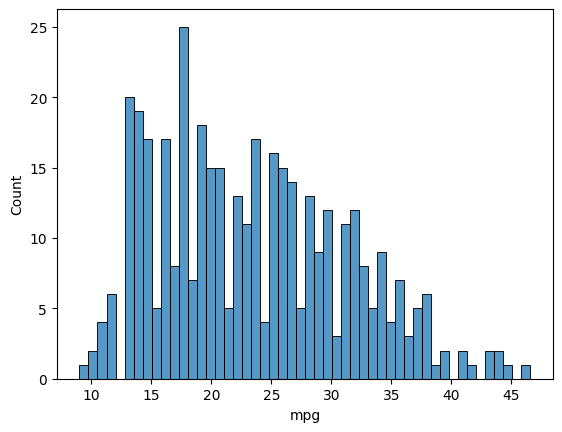

In [8]:
# распределение таргета
sns.histplot(df_mpg[target], bins=50)

In [9]:
# смотрим пропуски - обрабатывать обязательно!
df_mpg.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [10]:
# смотрим выбросы - только ненормальные значения обрабатываются на первой итерации
df_mpg[features].describe()

,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


<Axes: xlabel='horsepower', ylabel='Count'>

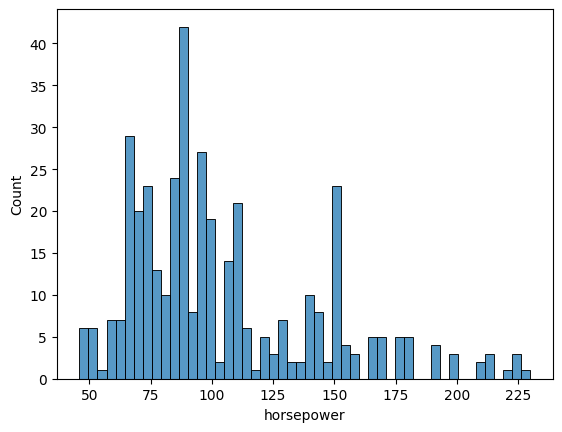

In [11]:
sns.histplot(df_mpg['horsepower'], bins=50)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(df_mpg[features],
                                                    df_mpg[target],
                                                    train_size=0.8,
                                                    random_state=42)

In [13]:
X_train.shape, X_test.shape

((318, 6), (80, 6))

In [14]:
# обработка пропусков - средним
mean_horsepower = X_train['horsepower'].mean()
mean_horsepower

np.float64(103.28434504792332)

In [15]:
X_train['horsepower'] = X_train['horsepower'].fillna(mean_horsepower)
X_test['horsepower'] = X_test['horsepower'].fillna(mean_horsepower)

In [16]:
X_train.isna().sum()

cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
dtype: int64

In [17]:
X_test.isna().sum()

cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
dtype: int64

In [ ]:
# ?LinearRegression

In [18]:
# строим модель
lin_model = LinearRegression()

In [19]:
lin_model

LinearRegression()

In [20]:
# выполнится ли этот код?
lin_model.predict(X_test)

NotFittedError: This LinearRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [21]:
lin_model.fit(X_train, y_train)

LinearRegression()

In [22]:
y_pred_test = lin_model.predict(X_test)
y_pred_test

array([31.53100066, 30.70876514, 21.76194314, 17.00377193, 12.61302683,
       26.21324367, 28.91129096,  9.20353629, 17.21953655, 22.74579566,
       12.68145245, 34.98791907, 26.69337402, 14.05843137, 24.77707145,
        5.90336575, 30.87257713, 23.81305083, 15.8809813 , 35.16334867,
       23.44499336, 19.69075296, 29.32876149, 30.33499375, 15.09755805,
       34.56195408, 25.77986672, 25.76025003, 22.17162712,  7.92223327,
       29.35882156, 34.94825054, 20.00737857, 24.92520638, 33.1036795 ,
       12.27810205, 24.47979548, 22.19736856, 12.3777133 , 26.96553906,
       27.64478739, 27.40746464, 20.293365  ,  7.75549155, 23.25676937,
       33.67984388, 26.58254279, 24.46995197, 22.78524086, 27.69247695,
       23.46862653, 32.51635882, 31.29683966, 10.59238332, 29.03332523,
        9.3740976 , 19.45918353, 28.30605391, 24.25241398, 20.7456282 ,
       16.5022124 , 30.73781665, 24.91738512, 20.29855644, 21.63436242,
       24.35614585, 25.87136015, 33.72519524, 29.33932962, 12.67

In [23]:
y_pred_train = lin_model.predict(X_train)
y_pred_train

array([15.64786536, 24.23975779, 34.82407019, 33.03754192, 24.3629907 ,
       10.77148207, 31.931723  , 31.7262754 , 25.95398025,  7.65090093,
       15.2572596 , 29.97018757, 26.52088767, 32.21131685, 23.7829104 ,
       33.84896304, 31.24303271, 24.10109769, 27.66845619, 12.8984145 ,
       32.90552708, 25.08436466, 20.11330632, 15.52747608, 19.44067654,
        9.57841815, 26.68049429, 10.21302211, 32.58053946, 34.45289348,
       29.92862276, 26.78575934, 21.75844589, 35.04388446, 27.70494439,
       24.35950746, 25.65242552, 23.36382842, 31.40417542, 22.1100031 ,
       12.78400285, 25.16024616, 21.43839235, 24.05211784, 20.94114477,
       27.80966632, 34.1286354 , 28.39701988, 34.06486185, 29.79937909,
       33.64568063, 28.60123292, 32.68520447, 21.19624361, 23.45659525,
       20.86826385, 22.24394341, 35.68257125, 30.53666891, 32.46170605,
       17.25444034, 10.65725677, 18.72381497, 21.74864526, 22.93254486,
       30.21249279, 25.59467289, 26.49836151, 28.79350718, 25.58

In [24]:
# посчитаем метрики
def get_metrics(y_pred, y_fact):
  mse = mean_squared_error(y_fact, y_pred)
  # rmse = mse**(1/2)
  rmse = root_mean_squared_error(y_fact, y_pred)
  mae = mean_absolute_error(y_fact, y_pred)
  r2 = r2_score(y_fact, y_pred)
  mape = mean_absolute_percentage_error(y_fact, y_pred)
  return {'mse':mse, 'rmse':rmse, 'mae':mae, 'mape':mape, 'r2':r2}

In [25]:
metrics_train = get_metrics(y_pred_train, y_train)
metrics_test = get_metrics(y_pred_test, y_test)

In [26]:
metrics_train

{'mse': 12.294936039233075,
 'rmse': 3.5064135579296796,
 'mae': 2.6967448334030077,
 'mape': 0.12398926552153626,
 'r2': 0.8038967013177779}

In [27]:
metrics_test

{'mse': 9.440915081847951,
 'rmse': 3.0726072124252966,
 'mae': 2.467213516613641,
 'mape': 0.12414683764128434,
 'r2': 0.8244087869053465}

> в целом можно считать модель непереобученной

In [32]:
# а теперь посмотрим распределение остатков
def get_res(y_pred, y_fact):
  res = y_fact - y_pred
  sns.histplot(res, bins=100)
  plt.title('y_fact - y_pred')
  plt.show()

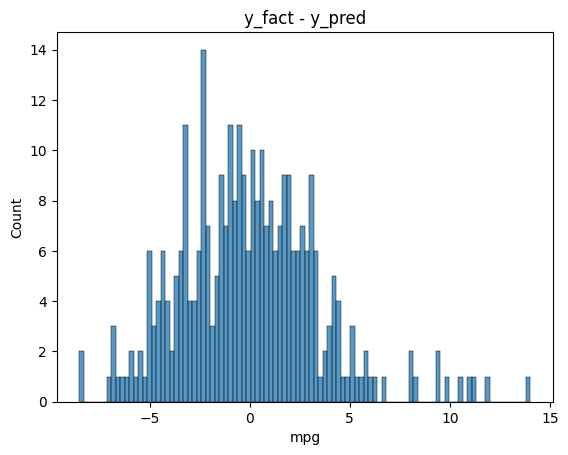

In [33]:
get_res(y_pred_train, y_train)

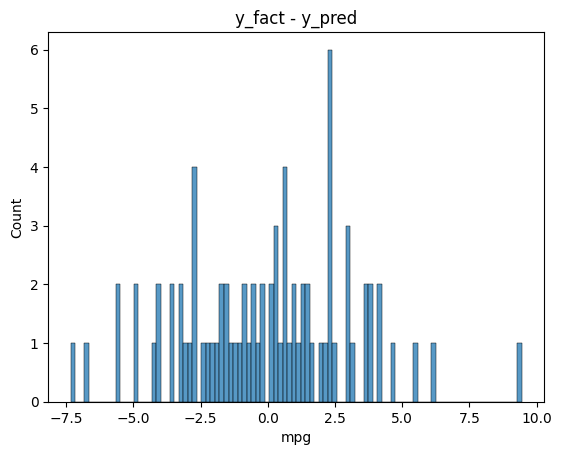

In [34]:
get_res(y_pred_test, y_test)

In [ ]:
# что делать если не помните, какой атрибут нужно заполнить в sns.histplot ?
?sns.histplot

Signature:
sns.histplot(
    data=None,
    *,
    x=None,
    y=None,
    hue=None,
    weights=None,
    stat='count',
    bins='auto',
    binwidth=None,
    binrange=None,
    discrete=None,
    cumulative=False,
    common_bins=True,
    common_norm=True,
    multiple='layer',
    element='bars',
    fill=True,
    shrink=1,
    kde=False,
    kde_kws=None,
    line_kws=None,
    thresh=0,
    pthresh=None,
    pmax=None,
    cbar=False,
    cbar_ax=None,
    cbar_kws=None,
    palette=None,
    hue_order=None,
    hue_norm=None,
    color=None,
    log_scale=None,
    legend=True,
    ax=None,
    **kwargs,
)
Docstring:
Plot univariate or bivariate histograms to show distributions of datasets.

A histogram is a classic visualization tool that represents the distribution
of one or more variables by counting the number of observations that fall within
discrete bins.

This function can normalize the statistic computed within each bin to estimate
frequency, density or probability mas

Улучшать можно практически бесконечно!

- пропуски - 5
- выбросы - 3
- отбор переменных - 3
- модели - 5

In [35]:
5*3*3*5

225

Попробуем добавить категориальные признаки.

Вернемся на первый шаг и посмотрим на исхоный датасет. 

Какие признаки будут категориальными?

In [38]:
df_mpg["origin"].unique()

array(['usa', 'japan', 'europe'], dtype=object)

In [39]:
df_mpg.head(100)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
95,12.0,8,455.0,225.0,4951,11.0,73,usa,buick electra 225 custom
96,13.0,8,360.0,175.0,3821,11.0,73,usa,amc ambassador brougham
97,18.0,6,225.0,105.0,3121,16.5,73,usa,plymouth valiant
98,16.0,6,250.0,100.0,3278,18.0,73,usa,chevrolet nova custom


In [40]:
df_mpg_cp = df_mpg.copy()
df_mpg_cp["short_name"] = df_mpg_cp["name"].apply(lambda x: x.split()[0])
df_mpg_cp = df_mpg_cp.drop('name', axis=1)
df_mpg_cp 

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,short_name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford


In [41]:
df_mpg_cp['origin'].unique()

array(['usa', 'japan', 'europe'], dtype=object)

In [42]:
df_mpg_cp['short_name'].unique()

array(['chevrolet', 'buick', 'plymouth', 'amc', 'ford', 'pontiac',
       'dodge', 'toyota', 'datsun', 'volkswagen', 'peugeot', 'audi',
       'saab', 'bmw', 'chevy', 'hi', 'mercury', 'opel', 'fiat',
       'oldsmobile', 'chrysler', 'mazda', 'volvo', 'renault', 'toyouta',
       'maxda', 'honda', 'subaru', 'chevroelt', 'capri', 'vw',
       'mercedes-benz', 'cadillac', 'mercedes', 'vokswagen', 'triumph',
       'nissan'], dtype=object)

In [43]:
cat_cols_ohe = ['origin', ]
cat_cols_freq = ['short_name', ]

In [44]:
# роли переменных
features = ['cylinders', 'displacement', 'horsepower', 'weight',
            'acceleration', 'model_year', 'origin', 'short_name', ]
target = 'mpg'

X_train, X_test, y_train, y_test = train_test_split(df_mpg_cp[features],
                                                    df_mpg_cp[target],
                                                    train_size=0.8,
                                                    random_state=42)

In [45]:
X_train.isna().sum()

cylinders       0
displacement    0
horsepower      5
weight          0
acceleration    0
model_year      0
origin          0
short_name      0
dtype: int64

In [46]:
X_test.isna().sum()

cylinders       0
displacement    0
horsepower      1
weight          0
acceleration    0
model_year      0
origin          0
short_name      0
dtype: int64

In [47]:
# обработка пропусков - средним
mean_horsepower = X_train['horsepower'].mean()
mean_horsepower

np.float64(103.28434504792332)

In [48]:
X_train['horsepower'] = X_train['horsepower'].fillna(mean_horsepower)
X_test['horsepower'] = X_test['horsepower'].fillna(mean_horsepower)

In [51]:
# OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
X_train_encoded = encoder.fit_transform(X_train[cat_cols_ohe])
X_test_encoded = encoder.transform(X_test[cat_cols_ohe])

Сколько будет колонок в X_train_encoded?

In [52]:
X_train_encoded

array([[0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 0.],
       [0., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 0.],
       [0., 1.],
       [0., 0.],
       [1., 0.],
       [1., 0.],
       [0., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 0.],
       [0., 1.],
       [0., 0.],
       [0., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.

In [53]:
# Получаем названия новых колонок
encoded_col_names = encoder.get_feature_names_out(cat_cols_ohe)
encoded_col_names

array(['origin_japan', 'origin_usa'], dtype=object)

In [54]:
# Преобразуем в DataFrame
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoded_col_names, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoded_col_names, index=X_test.index)

In [55]:
X_train_encoded_df.head()

,origin_japan,origin_usa
3,0.0,1.0
18,1.0,0.0
376,1.0,0.0
248,1.0,0.0
177,0.0,0.0


In [57]:
X_train.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,short_name,origin_japan,origin_usa
3,8,304.0,150.0,3433,12.0,70,amc,0.0,1.0
18,4,97.0,88.0,2130,14.5,70,datsun,1.0,0.0
376,4,91.0,68.0,2025,18.2,82,mazda,1.0,0.0
248,4,91.0,60.0,1800,16.4,78,honda,1.0,0.0
177,4,115.0,95.0,2694,15.0,75,audi,0.0,0.0


In [56]:
# Удаляем старые категориальные, добавляем закодированные
X_train = X_train.drop(columns=cat_cols_ohe).join(X_train_encoded_df)
X_test = X_test.drop(columns=cat_cols_ohe).join(X_test_encoded_df)

In [58]:
# Создаем CountEncoder с normalize=True
freq_encoder = ce.CountEncoder(cols=cat_cols_freq, normalize=True)

# Обучаем и трансформируем тренировочные данные (с нужными колонками)
X_train_encoded = freq_encoder.fit_transform(X_train[cat_cols_freq])

# Трансформируем тестовые данные
X_test_encoded = freq_encoder.transform(X_test[cat_cols_freq])



Сколько колонок будет в X_train_encoded?

In [59]:
X_train_encoded

,short_name
3,0.069182
18,0.069182
376,0.028302
248,0.028302
177,0.018868
...,...
71,0.028302
106,0.015723
270,0.066038
348,0.066038


In [60]:
# Добавляем закодированные колонки в исходные датасеты с суффиксом '_freq'
for col in cat_cols_freq:
    X_train[col + '_freq'] = X_train_encoded[col]
    X_train.drop(columns=col, inplace=True)
    X_test[col + '_freq'] = X_test_encoded[col]
    X_test.drop(columns=col, inplace=True)

In [61]:
X_train.sample(10)

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_japan,origin_usa,short_name_freq
283,6,232.0,90.0,3265,18.2,79,0.0,1.0,0.069182
327,5,121.0,67.0,2950,19.9,80,0.0,0.0,0.018868
364,8,350.0,105.0,3725,19.0,81,0.0,1.0,0.015723
117,4,68.0,49.0,1867,19.5,73,0.0,0.0,0.018868
102,4,97.0,46.0,1950,21.0,73,0.0,0.0,0.031447
176,6,232.0,90.0,3211,17.0,75,0.0,1.0,0.069182
392,4,151.0,90.0,2950,17.3,82,0.0,1.0,0.100629
206,4,140.0,72.0,2565,13.6,76,0.0,1.0,0.128931
338,4,135.0,84.0,2490,15.7,81,0.0,1.0,0.072327
388,4,156.0,92.0,2585,14.5,82,0.0,1.0,0.009434


Строим модель

In [62]:
# строим модель
lin_model = LinearRegression()

lin_model.fit(X_train, y_train)

y_pred_train = lin_model.predict(X_train)
print(y_pred_train)

y_pred_test = lin_model.predict(X_test)
print(y_pred_test)


[15.21694772 24.54522662 35.77577038 34.10840242 25.28788581 11.76735108
 32.87254058 29.70249391 26.24369496  8.7600005  16.20968006 30.22178785
 27.83452363 33.19362674 24.45966872 32.46583167 29.9000893  23.72671079
 26.29335779 12.67918479 30.93360956 25.47657255 19.16488156 15.13580095
 19.08439487 10.31364235 27.94937042 10.70007046 33.75353049 35.06160873
 30.17974951 27.74767699 21.04273679 36.0598066  26.24648729 22.65257139
 26.65350892 22.65852332 32.46942833 22.80251219 13.07120823 23.80172249
 20.3428505  23.03306643 20.13179575 28.67493913 35.10490014 27.07213661
 32.64374277 31.11633779 34.43050487 29.14743581 33.28131279 20.99095331
 24.42576868 20.55536878 22.3924466  36.63476292 28.73513249 33.61051397
 16.9807693   9.98335587 18.96343391 21.7611784  22.73254656 28.28166697
 26.69042938 26.96772423 26.99785727 26.13041206 10.05329237 20.27236303
 26.89841873 26.52074    15.263447   33.51191145  8.37133928 25.15716779
 19.40747884 32.08995265 26.510417   18.73336035 28

In [63]:
metrics_train = get_metrics(y_pred_train, y_train)
metrics_test = get_metrics(y_pred_test, y_test)

In [64]:
metrics_train

{'mse': 11.325849734340904,
 'rmse': 3.3653899825043907,
 'mae': 2.6067656208179892,
 'mape': 0.1200502184845088,
 'r2': 0.8193535544881158}

In [65]:
metrics_test

{'mse': 8.336585003878668,
 'rmse': 2.8873144968774476,
 'mae': 2.2621520628295086,
 'mape': 0.11590121292865625,
 'r2': 0.8449481791534954}

In [ ]:
get_res(y_pred_train, y_train)

In [ ]:
get_res(y_pred_test, y_test)